# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Based on the information provided in the UCI link and the paper, the dataset represents 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts and 41188 rows in the dataset.

The dataset has 21 columns, where 20 columns are considered input and one column is the target (indicating whether the client agrees to subscribe to a term deposit).

The 20 inputs are as follows (accordiong to the text file provided with the dataset)\
1 - age (numeric) \
2 - job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown") \
3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed) \
4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown") \
5 - default: has credit in default? (categorical: "no","yes","unknown") \
6 - housing: has housing loan? (categorical: "no","yes","unknown") \
7 - loan: has personal loan? (categorical: "no","yes","unknown") \
8 - contact: contact communication type (categorical: "cellular","telephone") \
9 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec") \
10 - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri") \
11 - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.\
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)\
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)\
14 - previous: number of contacts performed before this campaign and for this client (numeric)\
15 - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")\
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)\
17 - cons.price.idx: consumer price index - monthly indicator (numeric)\
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)\
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)\
20 - nr.employed: number of employees - quarterly indicator (numeric)

The Output variable (desired target) is Column 21:\
21 - y - has the client subscribed a term deposit? ("yes","no")

The objective of this analysis is to build and compare classification models that predict whether a customer will subscribe to a term deposit. The results can help the bank target its marketing resources more efficiently and reduce unnecessary calls.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

A few quick inspections into the dataset are as follows.

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.describe(include="object")

C:\Users\Alireza\AppData\Local\Temp\ipykernel_21908\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [8]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [9]:
df["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

As seen above, the data is highly unbalanced, so, some classification methods may not work as well as others.

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



#### 1. Unknown Values

In [10]:
(df == "unknown").sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

We will keep the unknown values and will treat 'unknown' as a cateogory when using OneHotEncoder. The reason is that we do not have a reason to believe whether the value being 'unknown' is a random feature of the dataset or contains useful information about the customer. 

#### 2. Special Value in pday
The value 999 means the customer was not previously contacted, not that the customer was contacted 999 days ago!

In [11]:
(df["pdays"] == 999).sum()

np.int64(39673)

We have a huge number of customers (almost 96.3%) that were not previously contacted. Only 3.7% were contacted before. So, we can just create a binary feature that indicates whether the customer was contacted before, and then drop pday.

In [12]:
df["previously_contacted"] = (df["pdays"] != 999).astype(int)
df = df.drop(columns="pdays")

#### 3. poutcome = "nonexistent"
"nonexistent" means that no previous campaign outcome exists, generally because the customer was not contacted previously. It can remain as its own category. However, we should make sure this column is consistent with the new column previously_contacted. If a person was not contacted previously, the corresponding value in poutcome should be "nonexistent" and vice versa.

In [13]:
df.loc[
    (df["poutcome"] == "nonexistent") &
    (df["previously_contacted"] == 1)
].shape[0]

0

In [14]:
df.loc[
    (df["previously_contacted"] == 0) &
    (df["poutcome"] != "nonexistent")
].shape[0]

4110

Therefore, there are 4,110 rows have this combination:
- previously_contacted = 0, because you created it from pdays == 999
- poutcome is either "failure" or "success", not "nonexistent"

So, df["previously_contacted"] = (df["pdays"] != 999).astype(int) is not really reliable. The issue is inaccuracy in the datasets. There seem to be 4,110 rows where pdays is 999, but a previous campaign outcome exists.

We will redefine previously_contacted based on the 'previous' column because its meaning is the number of contacts made before the current campaign:

In [15]:
df["previously_contacted"] = (df["previous"] > 0).astype(int)

In [16]:
(
    (df["poutcome"] == "nonexistent")
    ==
    (df["previously_contacted"] == 0)
).all()

np.True_

The columns 'previously_contacted' and 'poutcome' are now consistent.

#### 4. Target Variable
The target y is categorical and binary: yes or no. We can keep it categorical, because scikit-learn classifiers can generally handle string class labels. However, mapping it to 1 and 0 often makes evaluation and interpretation easier. Therefore, 


In [17]:
df["y"] = df["y"].map({
    "no": 0,
    "yes": 1
})

#### 5. Actual Missing Values

In [18]:
df.isna().sum()

age                     0
job                     0
marital                 0
education               0
default                 0
housing                 0
loan                    0
contact                 0
month                   0
day_of_week             0
duration                0
campaign                0
previous                0
poutcome                0
emp.var.rate            0
cons.price.idx          0
cons.conf.idx           0
euribor3m               0
nr.employed             0
y                       0
previously_contacted    0
dtype: int64

There is no missing value, as claimed by the dataset description. And as previously decided, we are keeping the 'unknown' values in the categorical columns for now.

#### 6. Data Cleaning
Now its time to clean the data.

##### 6.1. Remove the New Column (previously_contacted)
This new, derived feature may be redundant because:
- The column 'previous' already tells us how many earlier contacts occurred.
- The column 'poutcome' identifies whether the previous campaign was nonexistent, successful, or unsuccessful.

Therefore, we drop this new column.

In [19]:
df = df.drop(columns="previously_contacted")

##### 6.2. Define Groups

In [20]:
numerical_columns = [
    "age",
    "duration",
    "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

##### 6.3. Remove Leading and Trailing Spaces

In [21]:
for column in categorical_columns:
    df[column] = df[column].str.strip()

##### 6.4. Check Duplicates

In [22]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 12


There are 12 duplicate rows, but since we do not have customer ID, we do not have a way to know whether these duplicates are data entry errors. Therefore, we keep them. 

##### 6.5. Check Numerical Ranges and Impossible Values

In [23]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [24]:
print(
    "Invalid ages:",
    (df["age"] <= 0).sum()
)

print(
    "Negative durations:",
    (df["duration"] < 0).sum()
)

print(
    "Campaign values below 1:",
    (df["campaign"] < 1).sum()
)

print(
    "Negative previous contacts:",
    (df["previous"] < 0).sum()
)

Invalid ages: 0
Negative durations: 0
Campaign values below 1: 0
Negative previous contacts: 0


So, there are no impossible values (e.g., negative age values).

##### 6.6. Handle 'Duration' at the Modeling Stage
The feature 'duration' is unavailable before the call. Therefore, we keep it in df for exploratory purposes, but exclude it from the realistic prediction features:

In [25]:
X = df.drop(
    columns=["y", "duration"]
)

y = df["y"]

#### 7. Exploratory Data Analysis
Through plots, we perform some data analysis and explorations to better understand the features.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

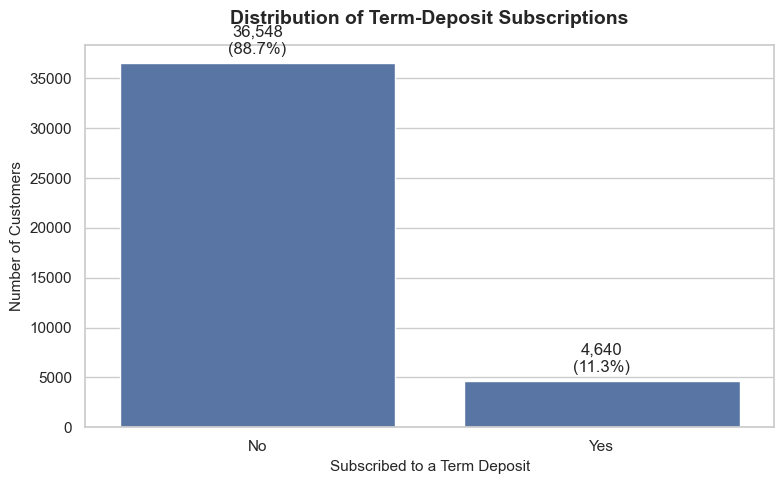

In [27]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="y",
    order=[0, 1]
)

ax.set_title(
    "Distribution of Term-Deposit Subscriptions",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Subscribed to a Term Deposit",
    fontsize=11
)

ax.set_ylabel(
    "Number of Customers",
    fontsize=11
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

total = len(df)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{int(bar.get_height()):,}\n"
            f"({bar.get_height() / total:.1%})"
            for bar in container
        ],
        padding=4
    )

plt.tight_layout()
plt.show()

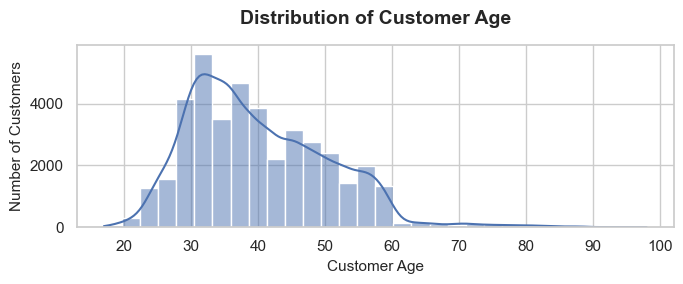

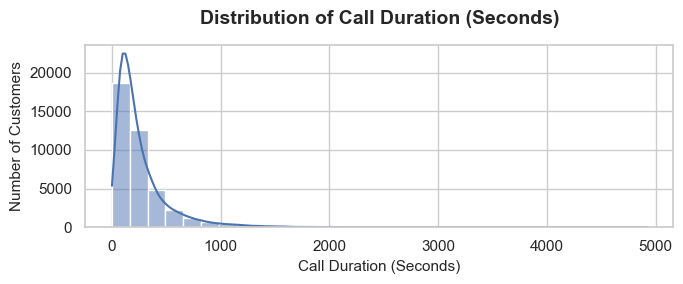

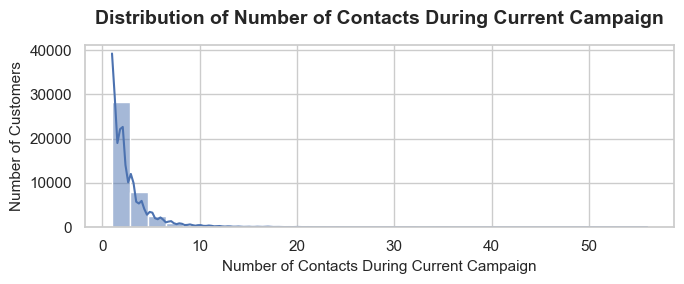

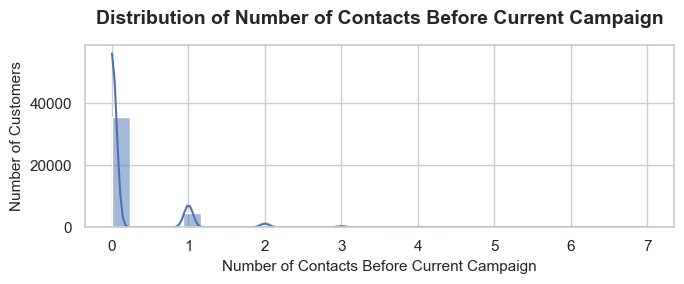

In [28]:
numerical_labels = {
    "age": "Customer Age",
    "duration": "Call Duration (Seconds)",
    "campaign": "Number of Contacts During Current Campaign",
    "previous": "Number of Contacts Before Current Campaign"
}
numerical_columns_plot = [
    "age",
    "duration",
    "campaign",
    "previous"
]
for column in numerical_columns_plot:
    plt.figure(figsize=(7, 3))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribution of {numerical_labels[column]}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.xlabel(
        numerical_labels[column],
        fontsize=11
    )

    plt.ylabel(
        "Number of Customers",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

We can compare numerical features by subscription outcome. Note that tge feature 'duration' is examined only during exploratory analysis, but it will be excluded from our predictive models because it is not known before the call occurs:

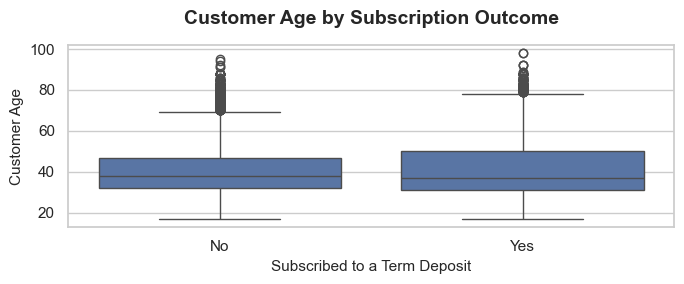

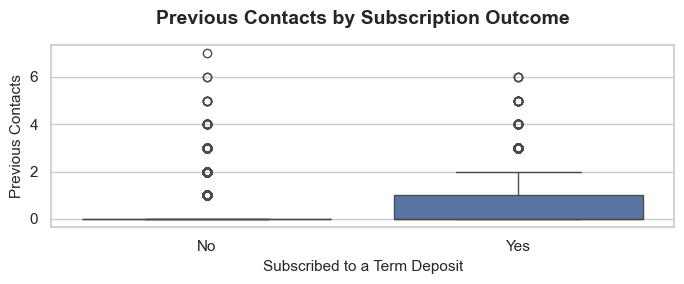

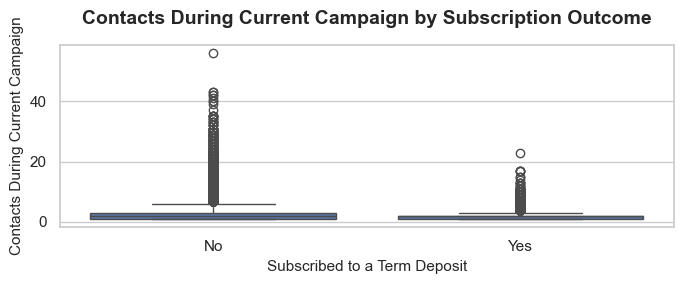

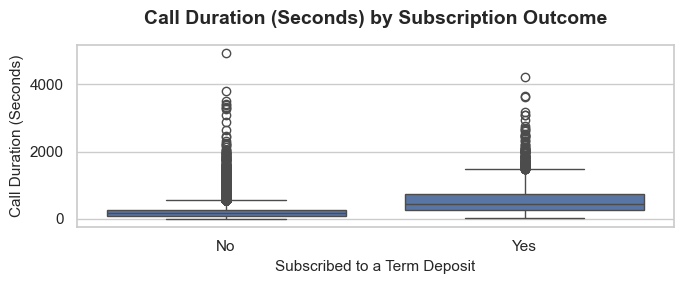

In [29]:
def plot_numeric_by_target(data, column, label):
    plt.figure(figsize=(7, 3))

    ax = sns.boxplot(
        data=data,
        x="y",
        y=column,
        order=[0, 1]
    )

    ax.set_title(
        f"{label} by Subscription Outcome",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Subscribed to a Term Deposit",
        fontsize=11
    )

    ax.set_ylabel(
        label,
        fontsize=11
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])

    plt.tight_layout()
    plt.show()

plot_numeric_by_target(
    df,
    "age",
    "Customer Age"
)

plot_numeric_by_target(
    df,
    "previous",
    "Previous Contacts"
)

plot_numeric_by_target(
    df,
    "campaign",
    "Contacts During Current Campaign"
)

plot_numeric_by_target(
    df,
    "duration",
    "Call Duration (Seconds)"
)

Similarly, we can examine categorical feature distributions:

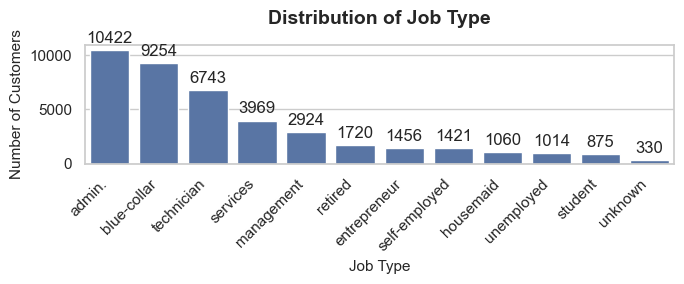

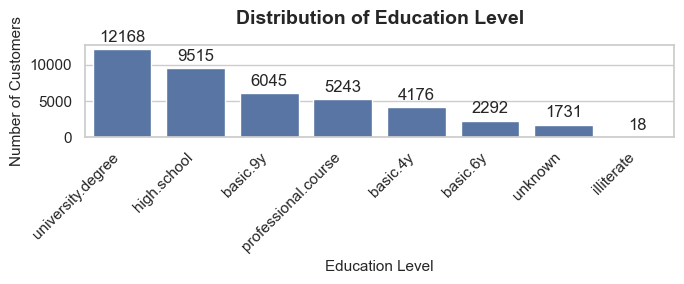

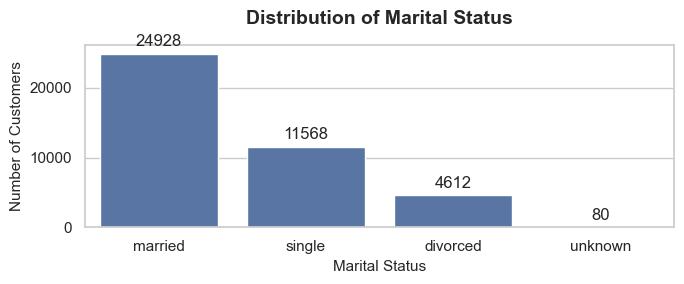

In [30]:
def plot_categorical_counts(
    data,
    column,
    label,
    order=None,
    rotate=0
):
    plt.figure(figsize=(7, 3))

    if order is None:
        order = data[column].value_counts().index

    ax = sns.countplot(
        data=data,
        x=column,
        order=order
    )

    ax.set_title(
        f"Distribution of {label}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        label,
        fontsize=11
    )

    ax.set_ylabel(
        "Number of Customers",
        fontsize=11
    )

    plt.xticks(
        rotation=rotate,
        ha="right" if rotate > 0 else "center"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3
        )

    plt.tight_layout()
    plt.show()

plot_categorical_counts(
    df,
    "job",
    "Job Type",
    rotate=45
)

plot_categorical_counts(
    df,
    "education",
    "Education Level",
    rotate=45
)

plot_categorical_counts(
    df,
    "marital",
    "Marital Status"
)

However, more insightful will be plots of subscription rates by categorical feature. Raw counts can be misleading because some categories contain many more customers than others For business interpretation, the subscription rate within each category is often more useful.

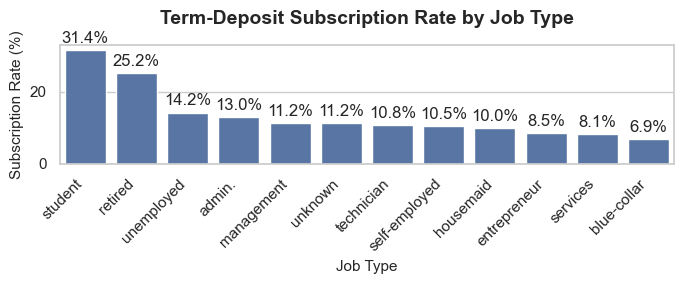

,job,count,subscription_rate
8,student,875,31.428571
5,retired,1720,25.232558
10,unemployed,1014,14.201183
0,admin.,10422,12.972558
4,management,2924,11.217510
11,unknown,330,11.212121
9,technician,6743,10.826042
6,self-employed,1421,10.485574
3,housemaid,1060,10.000000
2,entrepreneur,1456,8.516484


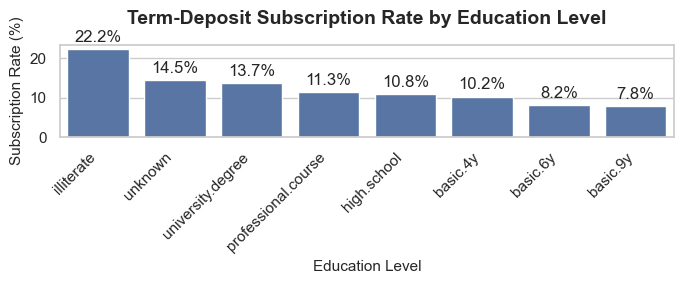

,education,count,subscription_rate
4,illiterate,18,22.222222
7,unknown,1731,14.500289
6,university.degree,12168,13.724523
5,professional.course,5243,11.348465
3,high.school,9515,10.835523
0,basic.4y,4176,10.249042
1,basic.6y,2292,8.202443
2,basic.9y,6045,7.824648


In [31]:
# Calculates the percentage of customers who subscribed in each category. 
df.groupby(column)["y"].mean()

def plot_subscription_rate(
    data,
    column,
    label,
    order=None,
    rotate=0
):
    rate_df = (
        data.groupby(column, observed=False)["y"]
        .agg(["mean", "count"])
        .reset_index()
    )

    rate_df["subscription_rate"] = (
        rate_df["mean"] * 100
    )

    if order is None:
        rate_df = rate_df.sort_values(
            "subscription_rate",
            ascending=False
        )
    else:
        rate_df[column] = pd.Categorical(
            rate_df[column],
            categories=order,
            ordered=True
        )

        rate_df = rate_df.sort_values(column)

    plt.figure(figsize=(7, 3))

    ax = sns.barplot(
        data=rate_df,
        x=column,
        y="subscription_rate"
    )

    ax.set_title(
        f"Term-Deposit Subscription Rate by {label}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        label,
        fontsize=11
    )

    ax.set_ylabel(
        "Subscription Rate (%)",
        fontsize=11
    )

    plt.xticks(
        rotation=rotate,
        ha="right" if rotate > 0 else "center"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

    return rate_df[
        [column, "count", "subscription_rate"]
    ]

job_rates = plot_subscription_rate(
    df,
    "job",
    "Job Type",
    rotate=45
)

display(job_rates)

education_rates = plot_subscription_rate(
    df,
    "education",
    "Education Level",
    rotate=45
)
display(education_rates)

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The objective of this analysis is to build and compare classification models that predict whether a customer will subscribe to a term deposit following a direct marketing campaign. By identifying customers who are more likely to subscribe, the bank can prioritize its outreach, allocate marketing resources more efficiently, reduce unnecessary calls, and potentially improve campaign conversion rates.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started. Before we can do this, we must work to encode the data. Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

We consider the bank client data at this stage.

In [32]:
bank_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

X = df[bank_features]
y = df["y"]

display(X.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


X shape: (41188, 7)
y shape: (41188,)


In [33]:
# Separate the features into numeric and categorical lists for preprocessing
numeric_features = ["age"]
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

As stated before, the "unknown" entries remain in the categorical columns. OneHotEncoder will treat "unknown" as an ordinary category.

We will do data split in Problem 6, but for coherence, it is done here as well.

In [34]:
from sklearn.model_selection import train_test_split

# Note: stratify=y preserves approximately the same proportion of subscribers and non-subscribers in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Now we can define transformations. We use StandardScaler for age and OneHotEncoder for the categorical features. Note: The command handle_unknown="ignore" prevents an error if a category appears in the test set that was not present in the training set. It does not remove the literal "unknown" category from your data.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

Next, we fit the transformations using only the training data and then apply the learned transformations to the test data:

In [36]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

It is important to note that fit_transform(X_train) learns the training mean, standard deviation, and category names, then transforms the training data. The command transform(X_test) uses those same learned values to transform the test data without learning from it.

Let's examine the transformed feature names:

In [37]:
encoded_feature_names = preprocessor.get_feature_names_out()

encoded_feature_names

array(['numeric__age', 'categorical__job_admin.',
       'categorical__job_blue-collar', 'categorical__job_entrepreneur',
       'categorical__job_housemaid', 'categorical__job_management',
       'categorical__job_retired', 'categorical__job_self-employed',
       'categorical__job_services', 'categorical__job_student',
       'categorical__job_technician', 'categorical__job_unemployed',
       'categorical__job_unknown', 'categorical__marital_divorced',
       'categorical__marital_married', 'categorical__marital_single',
       'categorical__marital_unknown', 'categorical__education_basic.4y',
       'categorical__education_basic.6y',
       'categorical__education_basic.9y',
       'categorical__education_high.school',
       'categorical__education_illiterate',
       'categorical__education_professional.course',
       'categorical__education_university.degree',
       'categorical__education_unknown', 'categorical__default_no',
       'categorical__default_unknown', 'categorical

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

This was done above but we can repeat here:

In [38]:
from sklearn.model_selection import train_test_split

# Note: stratify=y preserves approximately the same proportion of subscribers and non-subscribers in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

The baseline performance is that of a classifier that always predicts the majority class. Because most customers did not subscribe, the simplest baseline predicts 0 for every customer. According to the dataset, approximately 88.7% of customers did not subscribe. Therefore, the baseline accuracy is about 88.7%. This means a classifier that predicts "No" for every customer would still be correct almost 89% of the time.

In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline test accuracy: {baseline_accuracy:.2%}")

Baseline test accuracy: 88.74%


But we should note that the baseline classifier achieves zero precision, zero recall, and zero F1-score, because it does not identify any subscriber. Therefore, our classifier should not merely exceed approximately 88.7% accuracy. It should also achieve meaningful recall, precision, or F1-score for customers who actually subscribe—accuracy alone is not sufficient for evaluating the models.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Build the model
logistic_model = LogisticRegression(max_iter=1000)

# Train on the encoded training data
logistic_model.fit(X_train_encoded, y_train)

# Predict the test data
y_pred = logistic_model.predict(X_test_encoded)

### Problem 9: Score the Model

What is the accuracy of your model?

In [41]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8874
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


This simple initial Logistic Regression model achieves an accuracy of approximately 88.74%, which is essentially equal to the majority-class baseline. However, the model predicted every observation as a non-subscriber and failed to identify any actual subscribers. Consequently, its precision, recall, and F1-score for the subscriber class were all zero. This demonstrates that accuracy is misleading for this imbalanced dataset.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [42]:
import pandas as pd
from time import perf_counter

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [43]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [44]:
results = []
fitted_models = {}

for model_name, model in models.items():

    # Start timing before fitting
    start_time = perf_counter()

    # Train the model
    model.fit(X_train_encoded, y_train)

    # Stop timing after fitting
    train_time = perf_counter() - start_time

    # Calculate accuracy
    train_accuracy = model.score(
        X_train_encoded,
        y_train
    )

    test_accuracy = model.score(
        X_test_encoded,
        y_test
    )

    # Store the fitted model for later use
    fitted_models[model_name] = model

    # Store this model's results
    results.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

In [45]:
results_df = pd.DataFrame(results)

results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.118305,0.887344,0.887351
1,KNN,0.005701,0.891047,0.878126
2,Decision Tree,1.540279,0.917056,0.865016
3,SVM,124.787970,0.888164,0.886380


All models perform similarly in terms of test accuracy. The Decision Tree classifier has a slightly higher training accuracy because its default settings allow it to grow deeply without pruning. We should not interpret KNN’s short fitting time as meaning that it is necessarily the fastest model overall. KNN mainly stores the training data during .fit() and performs much of its computational work when making predictions. The default SVC() takes noticeably longer on this dataset because kernel SVC training scales at least quadratically with the number of observations and may become expensive with tens of thousands of rows. Finally, we should recall the roughly 88.7% majority-class baseline is high. A test accuracy near that value may still mean that a model identifies few or no subscribers. This table only shows the requested comparison, but precision, recall, F1-score, and confusion matrices should also be examined.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Because the target is imbalanced and the basic Logistic Regression model predicted every customer as a non-subscriber, accuracy should not be the metric optimized during grid search. A suitable primary metric is the positive-class F1-score, which balances precision and recall. In scikit-learn, GridSearchCV can evaluate several metrics while using F1 score to select and refit the best model.

##### Recreate the Unencoded Feature Data
For grid search, we use the original, unencoded columns and will place the preprocessing inside a pipeline so that scaling and encoding are fitted separately within each cross-validation fold, reducing preprocessing leakage.

In [46]:
from sklearn.model_selection import train_test_split

bank_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

X = df[bank_features]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### Define the Preprocessing

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["age"]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

##### Import the Models and Tools

In [55]:
import pandas as pd
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Use stratified cross-validation so that each fold maintains approximately the same target-class proportions
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

##### Select the Evaluation Metrics
The grid searches will calculate all four metrics, but refit="f1" tells GridSearchCV to choose and refit the parameter combination with the highest cross-validation F1-score.

In [56]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

refit="f1"

##### Why F1?
- Precision asks: Of the customers predicted to subscribe, what proportion actually subscribed?
- Recall asks: Of all actual subscribers, what proportion did the model find?
- F1-score balances precision and recall.

Because the business objective includes reducing unnecessary calls while still identifying likely subscribers, F1 is a reasonable starting metric.

##### Define the Hyperparameter Grids

In [57]:
logistic_grid = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

knn_grid = {
    "model__n_neighbors": [5, 11, 21],
    "model__weights": ["uniform", "distance"]
}

tree_grid = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

# Organize the models and grids
model_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        logistic_grid
    ),

    "KNN": (
        KNeighborsClassifier(),
        knn_grid
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        tree_grid
    ),

    "SVM": (
        SVC(),
        svm_grid
    )
}

##### Run Grid Search for Each Model

In [59]:
tuning_results = []
best_models = {}

for model_name, (model, param_grid) in model_grids.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=2
    )

    start_time = perf_counter()

    grid_search.fit(X_train, y_train)

    total_search_time = perf_counter() - start_time

    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    best_index = grid_search.best_index_

    tuning_results.append({
        "Model": model_name,
        "Search Time": total_search_time,
        "Best CV F1": grid_search.best_score_,
        "Train Accuracy": accuracy_score(
            y_train,
            y_train_pred
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),
        "Test Precision": precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "CV Accuracy": grid_search.cv_results_[
            "mean_test_accuracy"
        ][best_index],
        "CV Precision": grid_search.cv_results_[
            "mean_test_precision"
        ][best_index],
        "CV Recall": grid_search.cv_results_[
            "mean_test_recall"
        ][best_index],
        "Best Parameters": grid_search.best_params_
    })

    print(f"{model_name} completed.")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Logistic Regression completed.
Fitting 3 folds for each of 6 candidates, totalling 18 fits
KNN completed.
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Decision Tree completed.
Fitting 3 folds for each of 6 candidates, totalling 18 fits
SVM completed.


##### Result Table

In [61]:
tuned_results_df = pd.DataFrame(tuning_results)

tuned_results_display = tuned_results_df[
    [
        "Model",
        "Search Time",
        "Best CV F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
    ]
].copy()

metric_columns = [
    "Search Time",
    "Best CV F1",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
]

tuned_results_display[metric_columns] = (
    tuned_results_display[metric_columns].round(4)
)

tuned_results_display

,Model,Search Time,Best CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,14.9345,0.2556,0.5844,0.1581,0.6218,0.2521
1,KNN,212.8179,0.1399,0.8683,0.2671,0.0970,0.1423
2,Decision Tree,7.9630,0.2525,0.6506,0.1708,0.5453,0.2602
3,SVM,485.6427,0.2616,0.6066,0.1658,0.6185,0.2616


##### Conclusion
After hyperparameter tuning with F1-score as the main selection metric, the SVM achieved the highest test F1-score of 0.2616, closely followed by the Decision Tree at 0.2602 and Logistic Regression at 0.2521. Logistic Regression produced the highest recall, identifying approximately 62.2% of actual subscribers, but its low precision of 15.8% indicates that many customers predicted to subscribe were false positives. The SVM provided a similar balance between recall and precision but required the longest search time at approximately 486 seconds. In contrast, the Decision Tree achieved nearly the same test F1-score as the SVM while completing its grid search in only about 8 seconds, making it the most computationally efficient competitive model. KNN obtained the highest test accuracy of 86.8%, but its recall of 9.7% and F1-score of 0.1423 show that it largely favored the majority non-subscriber class and failed to identify most potential subscribers. Overall, the Decision Tree offers the best trade-off between predictive performance and computational cost, while Logistic Regression may be preferable when identifying as many potential subscribers as possible is the main priority. Nevertheless, the low precision and F1-scores across all models suggest that the bank-client features alone provide limited predictive information, and future analysis should consider additional campaign and economic features, probability-threshold adjustment, and further evaluation using precision-recall metrics.

##### 